# PART A: The Simulation (The World)
State space $\mathbf{S}_t = [y_t, v_t]^T$

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math

class BouncingBallSim:
    def __init__(self, y0=5.0, v0=0.0, g=9.8, m=1.0, dt=0.02, epsilon=0.8):
        self.y = y0; self.v = v0; self.g = g; self.m = m
        self.dt = dt; self.epsilon = epsilon; self.time = 0.0
        self.history_t = [self.time]
        self.history_y = [self.y]
        self.history_v = [self.v]
        self.history_e = [self.get_energy()]

    def get_state(self):
        return np.array([self.y, self.v], dtype=np.float32)

    def get_energy(self):
        return 0.5 * self.m * (self.v ** 2) + self.m * self.g * self.y

    def step(self, F=0.0):
        a = -self.g + (F / self.m)
        self.v += a * self.dt
        self.y += self.v * self.dt
        if self.y < 0:
            self.y = 0
            self.v = -self.epsilon * self.v
        self.time += self.dt
        self.history_t.append(self.time)
        self.history_y.append(self.y)
        self.history_v.append(self.v)
        self.history_e.append(self.get_energy())
        return self.get_state()

# Ready for instantiation.

## Physical Verification & Visualization

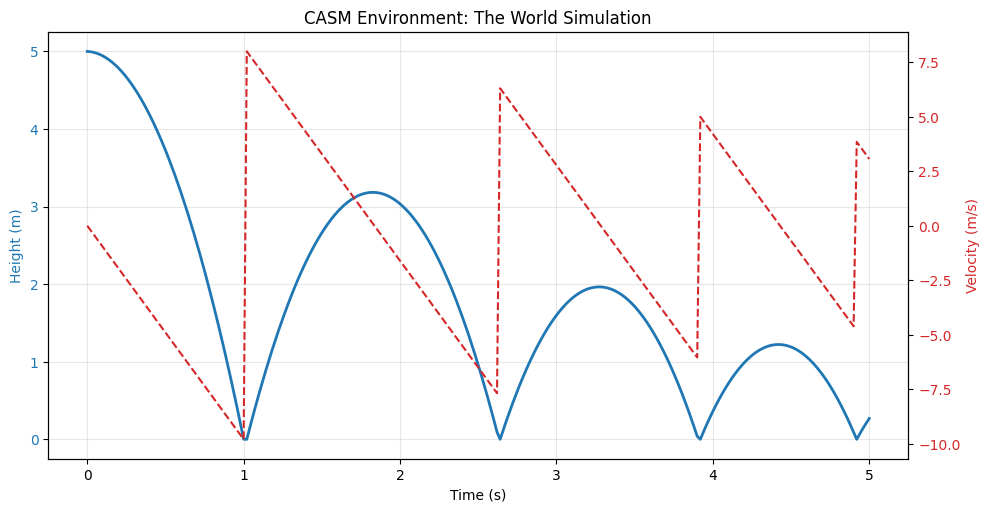

In [11]:
sim = BouncingBallSim(y0=5.0, v0=0.0)
for _ in range(250):
    sim.step()
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Height (m)', color=color)
ax1.plot(sim.history_t, sim.history_y, color=color, linewidth=2, label='Position (y)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Velocity (m/s)', color=color)
ax2.plot(sim.history_t, sim.history_v, color=color, linestyle='--', label='Velocity (v)')
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title('CASM Environment: The World Simulation')
plt.show()


# PART B: The World Model (Brain 1)
The GRU neural network mapping $(S_t, A_t) \to \hat{S}_{t+1}$

In [12]:
import torch
import torch.nn as nn

class Brain1WorldModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=2):
        super(Brain1WorldModel, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.prediction_head = nn.Linear(hidden_size, output_size)

    def forward(self, x, h_0=None):
        gru_out, h_n = self.gru(x, h_0)
        predictions = self.prediction_head(gru_out)
        return predictions, h_n


## Network Topology Verifications

In [13]:
brain = Brain1WorldModel()
dummy_input = torch.randn(32, 50, 3) # (Batch, Seq, Dim)
preds, next_hidden = brain(dummy_input)
print('Prediction Shape:', preds.shape)
loss = nn.MSELoss()(preds, torch.randn(32, 50, 2))
loss.backward()
print('Gradients Flowing:', all(p.grad is not None for p in brain.parameters()))
print('Parameters:', sum(p.numel() for p in brain.parameters()))


Prediction Shape: torch.Size([32, 50, 2])
Gradients Flowing: True
Parameters: 3618


# PART C: The Training Loop
The Brain 1 optimization mapping over $\mathcal{L}_t = \|\hat{S}_{t+1} - S_{t+1}\|^2$

In [14]:
import torch.optim as optim

def generate_batch(batch_size=32, seq_len=50):
    states = np.zeros((batch_size, seq_len + 1, 2), dtype=np.float32)
    actions = np.zeros((batch_size, seq_len, 1), dtype=np.float32)
    for b in range(batch_size):
        sim = BouncingBallSim(y0=np.random.uniform(1.0, 10.0), v0=np.random.uniform(-5.0, 5.0))
        states[b, 0] = sim.get_state()
        for t in range(seq_len):
            F = np.random.uniform(-2.0, 2.0)
            actions[b, t, 0] = F
            states[b, t+1] = sim.step(F)
    inputs = np.concatenate([states[:, :-1, :], actions], axis=-1)
    targets = states[:, 1:, :]
    return torch.tensor(inputs), torch.tensor(targets)

optimizer = optim.Adam(brain.parameters(), lr=0.001)
criterion = nn.MSELoss()

train_loss = []
for ep in range(1000):
    hx, hy = generate_batch()
    optimizer.zero_grad()
    preds, _ = brain(hx)
    loss = criterion(preds, hy)
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item())
    if (ep+1) % 100 == 0: print(f'Episode {ep+1:04d} | Loss: {loss.item():.4f}')


Episode 0100 | Loss: 7.8139
Episode 0200 | Loss: 2.9675
Episode 0300 | Loss: 1.6924
Episode 0400 | Loss: 1.2192
Episode 0500 | Loss: 1.6244
Episode 0600 | Loss: 0.9958
Episode 0700 | Loss: 0.6219
Episode 0800 | Loss: 0.8061
Episode 0900 | Loss: 0.7975
Episode 1000 | Loss: 0.6525


## Gravity Extraction Demonstration ($g \approx 9.8$)

In [15]:
brain.eval()
with torch.no_grad():
    print('Testing implicit physics discovery (Expected Δv = -0.196)')
    for y_i in [2.0, 5.0, 8.0, 12.0]:
        xin = torch.tensor([[[y_i, 0.0, 0.0]]], dtype=torch.float32)
        pred, _ = brain(xin)
        print(f'Init Height: {y_i} | Predicted Δv: {pred[0,0,1].item():.4f}')


Testing implicit physics discovery (Expected Δv = -0.196)
Init Height: 2.0 | Predicted Δv: 0.2463
Init Height: 5.0 | Predicted Δv: 0.1219
Init Height: 8.0 | Predicted Δv: -0.1774
Init Height: 12.0 | Predicted Δv: -0.5229


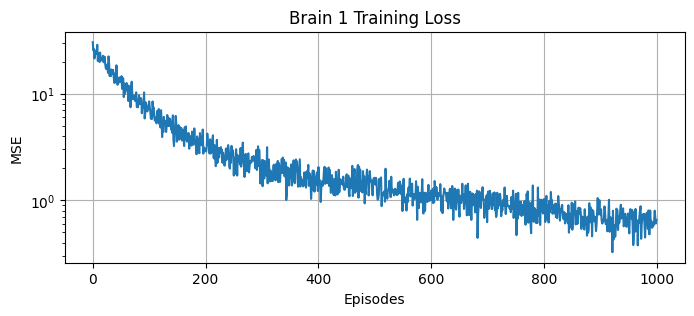

In [16]:
plt.figure(figsize=(8,3))
plt.plot(train_loss)
plt.title('Brain 1 Training Loss')
plt.xlabel('Episodes'); plt.ylabel('MSE')
plt.yscale('log')
plt.grid(True)
plt.show()


---
# PART D: Brain 1 v1.1 — The MLP Residual Fix

Based on the adversarial diagnosis, the GRU was pattern-matching sequence histories. We now implement the theoretically correct architecture for learning local Markovian dynamics:
1. **Architecture:** MLP (No memory, No hidden state)
2. **Target:** Predict Change ($\Delta y, \Delta v$), not absolute state.
3. **Data:** Train on shuffled, individual transitions, not ordered sequences.


In [20]:
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------------------------------------
# 1. The Fixed Architecture: MLP for Residuals
# ---------------------------------------------------------
class Brain1_v2(nn.Module):
    def __init__(self):
        super(Brain1_v2, self).__init__()
        # Input: [y_t, v_t, F_t] -> Output: [\Delta y, \Delta v]
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        
    def forward(self, x):
        return self.net(x)

brain1_v2 = Brain1_v2()
print(f"Brain 1 v1.1 Parameter Count: {sum(p.numel() for p in brain1_v2.parameters())}")

# ---------------------------------------------------------
# 2. Collect Shuffled Training Data
# ---------------------------------------------------------
print("Collecting 50,000 random transitions...")
data_pool = []

for _ in range(1000):
    sim = BouncingBallSim()
    # Randomize initial state 
    sim.y = random.uniform(1.0, 10.0) # y
    sim.v = random.uniform(-5.0, 5.0) # v
    
    for _ in range(50):
        y_t, v_t = sim.y, sim.v
        F_t = random.uniform(-2.0, 2.0)
        
        sim.step(F_t)
        
        y_t1, v_t1 = sim.y, sim.v
        
        # Calculate true residuals (change)
        dy = y_t1 - y_t
        dv = v_t1 - v_t
        
        data_pool.append([y_t, v_t, F_t, dy, dv])

# Convert to tensors
import numpy as np
data_tensor = torch.FloatTensor(data_pool)

# Inputs: [y_t, v_t, F_t]
X = data_tensor[:, :3]
# Targets: [\Delta y, \Delta v]
Y = data_tensor[:, 3:]

# Create DataLoader for random batching
dataset = TensorDataset(X, Y)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print(f"Dataset created with {len(dataset)} transitions. Ready for training.")


Brain 1 v1.1 Parameter Count: 4546
Dataset created with 50000 transitions. Ready for training.


Training Brain 1 v1.1 (MLP Residuals)...
Epoch [10/100], Loss: 0.145821
Epoch [20/100], Loss: 0.129559
Epoch [30/100], Loss: 0.130316
Epoch [40/100], Loss: 0.105633
Epoch [50/100], Loss: 0.086266
Epoch [60/100], Loss: 0.077319
Epoch [70/100], Loss: 0.061603
Epoch [80/100], Loss: 0.062208
Epoch [90/100], Loss: 0.045331
Epoch [100/100], Loss: 0.042356


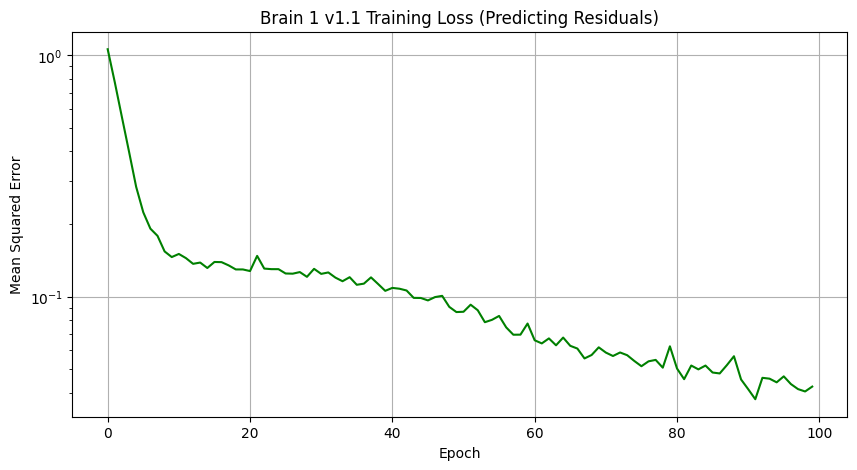

In [21]:
# ---------------------------------------------------------
# 3. Train on Shuffled Transitions
# ---------------------------------------------------------
optimizer_v2 = optim.Adam(brain1_v2.parameters(), lr=0.001)
criterion = nn.MSELoss()

epochs = 100
loss_history_v2 = []

print("Training Brain 1 v1.1 (MLP Residuals)...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_Y in dataloader:
        
        # Forward pass
        predictions = brain1_v2(batch_X)
        
        # Loss
        loss = criterion(predictions, batch_Y)
        
        # Backward and optimize
        optimizer_v2.zero_grad()
        loss.backward()
        optimizer_v2.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(dataloader)
    loss_history_v2.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(loss_history_v2, color='green')
plt.title('Brain 1 v1.1 Training Loss (Predicting Residuals)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.yscale('log')
plt.grid(True)
plt.show()


In [23]:
# ---------------------------------------------------------
# 4. The Critical Tests
# ---------------------------------------------------------
brain1_v2.eval()
print("==== GRAVITY EXTRACTION TEST (v1.1) ====")
print("Hypothesis: \\Delta v should be approx -0.196 regardless of height.")

test_heights = [2.0, 5.0, 8.0, 12.0, 20.0, 50.0]
with torch.no_grad():
    for h in test_heights:
        # [y=h, v=0, F=0]
        test_input = torch.tensor([[h, 0.0, 0.0]], dtype=torch.float32)
        prediction = brain1_v2(test_input)
        pred_dv = prediction[0, 1].item()
        print(f"Height {h:4.1f} -> Predicted \\Delta v = {pred_dv:7.4f}")

print("\n==== FORCE RESPONSE TEST (v1.1) ====")
print("Hypothesis: \\Delta v = (-g + F/m) * dt")
print("Expected: a = -9.8 + F -> \\Delta v = a * 0.02")

test_forces = [-5.0, -2.0, 0.0, 2.0, 5.0, 9.8]
with torch.no_grad():
    for f in test_forces:
        # [y=5.0, v=0, F=f]
        test_input = torch.tensor([[5.0, 0.0, f]], dtype=torch.float32)
        prediction = brain1_v2(test_input)
        pred_dv = prediction[0, 1].item()
        
        # Theoretical calculation
        theoretical_a = -9.8 + f
        theoretical_dv = theoretical_a * 0.02
        
        print(f"Force {f:4.1f} -> Predicted \\Delta v = {pred_dv:7.4f} (Theoretical: {theoretical_dv:7.4f})")


==== GRAVITY EXTRACTION TEST (v1.1) ====
Hypothesis: \Delta v should be approx -0.196 regardless of height.
Height  2.0 -> Predicted \Delta v = -0.1886
Height  5.0 -> Predicted \Delta v = -0.1804
Height  8.0 -> Predicted \Delta v = -0.1722
Height 12.0 -> Predicted \Delta v = -0.1612
Height 20.0 -> Predicted \Delta v = -0.1393
Height 50.0 -> Predicted \Delta v = -0.0571

==== FORCE RESPONSE TEST (v1.1) ====
Hypothesis: \Delta v = (-g + F/m) * dt
Expected: a = -9.8 + F -> \Delta v = a * 0.02
Force -5.0 -> Predicted \Delta v = -0.2734 (Theoretical: -0.2960)
Force -2.0 -> Predicted \Delta v = -0.2213 (Theoretical: -0.2360)
Force  0.0 -> Predicted \Delta v = -0.1804 (Theoretical: -0.1960)
Force  2.0 -> Predicted \Delta v = -0.1406 (Theoretical: -0.1560)
Force  5.0 -> Predicted \Delta v = -0.0822 (Theoretical: -0.0960)
Force  9.8 -> Predicted \Delta v = -0.0002 (Theoretical:  0.0000)
